# HW13 – токенизация текста, инференс BERT и базовый fine-tuning для классификации

В этой работе:
- загружается датасет `emotion`;
- показывается разбор токенизации текста для BERT-подобной модели;
- выполняется инференс готовой pretrained-модели;
- проводится базовый fine-tuning компактной BERT-подобной модели;
- считается качество на test-части, строится матрица ошибок и сохраняются артефакты.

In [1]:
import os
import sys
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import datasets
import transformers

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 200)
pd.set_option("display.precision", 4)

In [2]:
SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
ARTIFACTS_DIR = Path("./artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts directory:", ARTIFACTS_DIR.resolve())

Artifacts directory: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW13\artifacts


In [4]:
print("Python:", sys.version)
print("Platform:", platform.platform())
print("datasets:", datasets.__version__)
print("transformers:", transformers.__version__)
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
datasets: 4.8.4
transformers: 5.5.0
torch: 2.10.0+cpu
CUDA available: False


## 1. Загрузка датасета и первичный анализ

In [5]:
DATASET_NAME = "emotion"
raw_dataset = load_dataset(DATASET_NAME)

raw_dataset

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [6]:
label_names = raw_dataset["train"].features["label"].names
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in id2label.items()}

print("Label names:", label_names)
print("Number of classes:", len(label_names))
print("id2label:", id2label)
print("label2id:", label2id)

Label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Number of classes: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}


In [7]:
split_sizes = {split: len(raw_dataset[split]) for split in raw_dataset.keys()}
split_sizes

{'train': 16000, 'validation': 2000, 'test': 2000}

In [8]:
def make_preview_df(dataset_split, n=5):
    rows = []
    for i in range(min(n, len(dataset_split))):
        rows.append({
            "text": dataset_split[i]["text"],
            "label_id": dataset_split[i]["label"],
            "label_name": id2label[dataset_split[i]["label"]],
        })
    return pd.DataFrame(rows)

print("Train examples:")
display(make_preview_df(raw_dataset["train"], 5))

print("Validation examples:")
display(make_preview_df(raw_dataset["validation"], 5))

print("Test examples:")
display(make_preview_df(raw_dataset["test"], 5))

Train examples:


,text,label_id,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2,love
4,i am feeling grouchy,3,anger


Validation examples:


,text,label_id,label_name
0,im feeling quite sad and sorry for myself but ill snap out of it soon,0,sadness
1,i feel like i am still looking at a blank canvas blank pieces of paper,0,sadness
2,i feel like a faithful servant,2,love
3,i am just feeling cranky and blue,3,anger
4,i can have for a treat or if i am feeling festive,1,joy


Test examples:


,text,label_id,label_name
0,im feeling rather rotten so im not very ambitious right now,0,sadness
1,im updating my blog because i feel shitty,0,sadness
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,0,sadness
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,1,joy
4,i was feeling a little vain when i did this one,0,sadness


Краткий комментарий:

Датасет `emotion` содержит короткие англоязычные тексты, где нужно предсказать одну из 6 эмоций:
` sadness, joy, love, anger, fear, surprise `.
Это удобная учебная постановка, потому что классы понятны, есть готовые split-части
`train / validation / test`, а длина текстов обычно небольшая.

## 2. Разбор токенизации

In [14]:
TOKENIZER_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

print("Tokenizer:", TOKENIZER_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model max length:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: bert-base-uncased
Tokenizer class: BertTokenizer
Model max length: 512


In [15]:
text = "I am very happy today because everything worked well."

encoded = tokenizer(text)

print(encoded)
print(tokenizer.tokenize(text))
print(tokenizer.convert_ids_to_tokens(encoded["input_ids"]))

{'input_ids': [101, 1045, 2572, 2200, 3407, 2651, 2138, 2673, 2499, 2092, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
['i', 'am', 'very', 'happy', 'today', 'because', 'everything', 'worked', 'well', '.']
['[CLS]', 'i', 'am', 'very', 'happy', 'today', 'because', 'everything', 'worked', 'well', '.', '[SEP]']


## 2. Разбор токенизации

In [16]:
special_tokens_df = pd.DataFrame({
    "token_name": ["cls_token", "sep_token", "pad_token", "unk_token", "mask_token"],
    "token": [
        tokenizer.cls_token,
        tokenizer.sep_token,
        tokenizer.pad_token,
        tokenizer.unk_token,
        tokenizer.mask_token,
    ],
    "token_id": [
        tokenizer.cls_token_id,
        tokenizer.sep_token_id,
        tokenizer.pad_token_id,
        tokenizer.unk_token_id,
        tokenizer.mask_token_id,
    ]
})

display(special_tokens_df)

,token_name,token,token_id
0,cls_token,[CLS],101
1,sep_token,[SEP],102
2,pad_token,[PAD],0
3,unk_token,[UNK],100
4,mask_token,[MASK],103


In [17]:
sample_texts = [
    "I am feeling very happy today because everything worked out well.",
    "This situation makes me nervous and afraid of what happens next.",
    "I cannot believe it, this was such a wonderful surprise!",
    "I am angry that nobody listened to my warning.",
    "I love how thoughtful and kind this message is.",
]

In [18]:
def inspect_tokenization(text: str, tokenizer) -> pd.DataFrame:
    encoded = tokenizer(
        text,
        add_special_tokens=True,
        return_attention_mask=True,
        return_token_type_ids=True,
        truncation=True,
        max_length=32,
    )
    input_ids = encoded["input_ids"]
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    token_type_ids = encoded.get("token_type_ids", [0] * len(input_ids))

    df = pd.DataFrame({
        "position": list(range(len(input_ids))),
        "token": tokens,
        "input_id": input_ids,
        "attention_mask": encoded["attention_mask"],
        "token_type_id": token_type_ids,
    })
    return df

for text in sample_texts[:3]:
    print("=" * 100)
    print("TEXT:")
    print(text)
    display(inspect_tokenization(text, tokenizer))

TEXT:
I am feeling very happy today because everything worked out well.


,position,token,input_id,attention_mask,token_type_id
0,0,[CLS],101,1,0
1,1,i,1045,1,0
2,2,am,2572,1,0
3,3,feeling,3110,1,0
4,4,very,2200,1,0
5,5,happy,3407,1,0
6,6,today,2651,1,0
7,7,because,2138,1,0
8,8,everything,2673,1,0
9,9,worked,2499,1,0


TEXT:
This situation makes me nervous and afraid of what happens next.


,position,token,input_id,attention_mask,token_type_id
0,0,[CLS],101,1,0
1,1,this,2023,1,0
2,2,situation,3663,1,0
3,3,makes,3084,1,0
4,4,me,2033,1,0
5,5,nervous,6091,1,0
6,6,and,1998,1,0
7,7,afraid,4452,1,0
8,8,of,1997,1,0
9,9,what,2054,1,0


TEXT:
I cannot believe it, this was such a wonderful surprise!


,position,token,input_id,attention_mask,token_type_id
0,0,[CLS],101,1,0
1,1,i,1045,1,0
2,2,cannot,3685,1,0
3,3,believe,2903,1,0
4,4,it,2009,1,0
5,5,",",1010,1,0
6,6,this,2023,1,0
7,7,was,2001,1,0
8,8,such,2107,1,0
9,9,a,1037,1,0


In [19]:
text_a = "I am happy because the exam went great."
text_b = "Still, I am a bit nervous about the final grade."

pair_encoded = tokenizer(
    text_a,
    text_b,
    add_special_tokens=True,
    return_attention_mask=True,
    return_token_type_ids=True,
    truncation=True,
    max_length=24,
)

pair_tokens = tokenizer.convert_ids_to_tokens(pair_encoded["input_ids"])

pair_df = pd.DataFrame({
    "position": list(range(len(pair_encoded["input_ids"]))),
    "token": pair_tokens,
    "input_id": pair_encoded["input_ids"],
    "attention_mask": pair_encoded["attention_mask"],
    "token_type_id": pair_encoded.get("token_type_ids", [0] * len(pair_encoded["input_ids"])),
})

display(pair_df)

,position,token,input_id,attention_mask,token_type_id
0,0,[CLS],101,1,0
1,1,i,1045,1,0
2,2,am,2572,1,0
3,3,happy,3407,1,0
4,4,because,2138,1,0
5,5,the,1996,1,0
6,6,exam,11360,1,0
7,7,went,2253,1,0
8,8,great,2307,1,0
9,9,.,1012,1,0


In [20]:
padding_examples = [
    "I am happy.",
    "I am extremely happy because the whole project finally works correctly.",
    "This is a very long sentence that will be truncated on purpose to demonstrate how max_length, padding and truncation affect transformer inputs.",
]

batch_encoded = tokenizer(
    padding_examples,
    padding=True,
    truncation=True,
    max_length=12,
    return_attention_mask=True,
)

rows = []
for i, text in enumerate(padding_examples):
    rows.append({
        "text": text,
        "encoded_length": len(batch_encoded["input_ids"][i]),
        "input_ids": batch_encoded["input_ids"][i],
        "attention_mask": batch_encoded["attention_mask"][i],
        "tokens": tokenizer.convert_ids_to_tokens(batch_encoded["input_ids"][i]),
    })

padding_df = pd.DataFrame(rows)
display(padding_df)

,text,encoded_length,input_ids,attention_mask,tokens
0,I am happy.,12,"[101, 1045, 2572, 3407, 1012, 102, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]","[[CLS], i, am, happy, ., [SEP], [PAD], [PAD], [PAD], [PAD], [PAD], [PAD]]"
1,I am extremely happy because the whole project finally works correctly.,12,"[101, 1045, 2572, 5186, 3407, 2138, 1996, 2878, 2622, 2633, 2573, 102]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[[CLS], i, am, extremely, happy, because, the, whole, project, finally, works, [SEP]]"
2,"This is a very long sentence that will be truncated on purpose to demonstrate how max_length, padding and truncation affect transformer inputs.",12,"[101, 2023, 2003, 1037, 2200, 2146, 6251, 2008, 2097, 2022, 25449, 102]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[[CLS], this, is, a, very, long, sentence, that, will, be, truncated, [SEP]]"


### Краткий вывод по токенизации

- текст превращается не в обычные слова, а в токены / подслова;
- в последовательность добавляются special tokens `[CLS]` и `[SEP]`;
- `input_ids` — это численные id токенов;
- `attention_mask` показывает, где реальные токены, а где padding;
- при `truncation=True` длинные тексты обрезаются до `max_length`.

## 3. Инференс готовой pretrained-модели

In [21]:
READY_MODEL_NAME = "nateraw/bert-base-uncased-emotion"

pipeline_device = 0 if torch.cuda.is_available() else -1

ready_clf = pipeline(
    task="text-classification",
    model=READY_MODEL_NAME,
    tokenizer=READY_MODEL_NAME,
    device=pipeline_device,
)

config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: nateraw/bert-base-uncased-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [22]:
inference_texts = [
    "I am so happy that my final project works!",
    "I am terrified that I will fail tomorrow.",
    "I feel angry and disappointed after reading that email.",
    "This gift was unexpected and made me smile.",
    "I really love spending time with my family.",
    "I feel empty and sad after the meeting.",
]

ready_outputs = ready_clf(inference_texts)

ready_df = pd.DataFrame({
    "text": inference_texts,
    "pred_label": [item["label"] for item in ready_outputs],
    "score": [item["score"] for item in ready_outputs],
})

display(ready_df)

,text,pred_label,score
0,I am so happy that my final project works!,joy,0.9939
1,I am terrified that I will fail tomorrow.,fear,0.9925
2,I feel angry and disappointed after reading that email.,anger,0.9930
3,This gift was unexpected and made me smile.,joy,0.9919
4,I really love spending time with my family.,joy,0.9355
5,I feel empty and sad after the meeting.,sadness,0.9965


### Краткий комментарий по готовому инференсу

Готовая модель показывает разумные результаты, потому что она уже обучена на задаче
распознавания эмоций и пространство меток хорошо совпадает с выбранным датасетом `emotion`.
Но даже в таком случае её ответы не стоит считать идеальными:
на коротких, неоднозначных или смешанных формулировках модель может ошибаться.

## 4. Подготовка данных для fine-tuning

In [23]:
FAST_RUN = False

TRAIN_LIMIT = 4000
VALID_LIMIT = 1000
TEST_LIMIT = 1000

if FAST_RUN:
    train_ds = raw_dataset["train"].shuffle(seed=SEED).select(range(min(TRAIN_LIMIT, len(raw_dataset["train"]))))
    valid_ds = raw_dataset["validation"].shuffle(seed=SEED).select(range(min(VALID_LIMIT, len(raw_dataset["validation"]))))
    test_ds = raw_dataset["test"].shuffle(seed=SEED).select(range(min(TEST_LIMIT, len(raw_dataset["test"]))))
else:
    train_ds = raw_dataset["train"]
    valid_ds = raw_dataset["validation"]
    test_ds = raw_dataset["test"]

print("Train size:", len(train_ds))
print("Validation size:", len(valid_ds))
print("Test size:", len(test_ds))

Train size: 16000
Validation size: 2000
Test size: 2000


In [26]:
FT_MODEL_NAME = "distilbert-base-uncased"
ft_tokenizer = AutoTokenizer.from_pretrained(FT_MODEL_NAME)

MAX_LENGTH = 128

def tokenize_batch(batch):
    return ft_tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [27]:
tokenized_train = train_ds.map(tokenize_batch, batched=True)
tokenized_valid = valid_ds.map(tokenize_batch, batched=True)
tokenized_test = test_ds.map(tokenize_batch, batched=True)

keep_columns = {"label", "input_ids", "attention_mask", "token_type_ids"}

remove_train = [c for c in tokenized_train.column_names if c not in keep_columns]
remove_valid = [c for c in tokenized_valid.column_names if c not in keep_columns]
remove_test = [c for c in tokenized_test.column_names if c not in keep_columns]

tokenized_train = tokenized_train.remove_columns(remove_train)
tokenized_valid = tokenized_valid.remove_columns(remove_valid)
tokenized_test = tokenized_test.remove_columns(remove_test)

tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_valid = tokenized_valid.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

print(tokenized_train)
print(tokenized_valid)
print(tokenized_test)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 16000
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})


In [28]:
data_collator = DataCollatorWithPadding(tokenizer=ft_tokenizer)

sample_batch = [tokenized_train[i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

labels: shape=(3,)
input_ids: shape=(3, 23)
token_type_ids: shape=(3, 23)
attention_mask: shape=(3, 23)


## 5. Модель, метрики и параметры обучения

In [29]:
model = AutoModelForSequenceClassification.from_pretrained(
    FT_MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

model.to(device)

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model class: DistilBertForSequenceClassification
Number of labels: 6


In [30]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
    }

In [31]:
common_training_kwargs = dict(
    output_dir="./trainer_output",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [32]:
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_valid,
        processing_class=ft_tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_valid,
        tokenizer=ft_tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

## 6. Fine-tuning

In [33]:
train_result = trainer.train()
train_result

C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.212303,0.191473,0.931500,0.904215
2,0.119292,0.146767,0.937500,0.910742
3,0.107800,0.144251,0.942000,0.915115


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3000, training_loss=0.2494752221107483, metrics={'train_runtime': 5449.3601, 'train_samples_per_second': 8.808, 'train_steps_per_second': 0.551, 'total_flos': 584777647046016.0, 'train_loss': 0.2494752221107483, 'epoch': 3.0})

In [34]:
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.tail(10))

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
54,0.0859,5.6206,2.3400e-06,2.65,2650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,0.1090,3.3665,2.0067e-06,2.70,2700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,0.0836,1.9713,1.6733e-06,2.75,2750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,0.0682,11.1893,1.3400e-06,2.80,2800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,0.1235,3.9033,1.0067e-06,2.85,2850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,0.1197,7.6792,6.7333e-07,2.90,2900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,0.0960,1.5282,3.4000e-07,2.95,2950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,0.1078,3.9600,6.6667e-09,3.00,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62,NaN,NaN,NaN,3.00,3000,0.1443,0.942,0.9151,52.6385,37.995,2.375,NaN,NaN,NaN,NaN,NaN
63,NaN,NaN,NaN,3.00,3000,NaN,NaN,NaN,NaN,NaN,NaN,5449.3601,8.808,0.551,5.8478e+14,0.2495


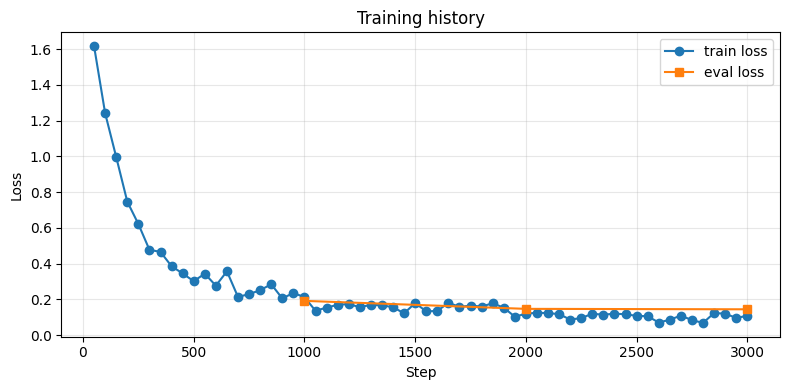

Saved: artifacts\training_curves.png


In [35]:
plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("Training history")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

training_curves_path = ARTIFACTS_DIR / "training_curves.png"
plt.savefig(training_curves_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", training_curves_path)

## 7. Оценка на validation и test

In [37]:
from transformers.utils.notebook import NotebookProgressCallback

try:
    trainer.remove_callback(NotebookProgressCallback)
    print("NotebookProgressCallback removed")
except Exception as e:
    print("Callback was not removed:", e)

NotebookProgressCallback removed


In [39]:
val_metrics = trainer.evaluate(eval_dataset=tokenized_valid)
test_metrics = trainer.evaluate(eval_dataset=tokenized_test)

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 0.1443
eval_accuracy: 0.9420
eval_f1_macro: 0.9151
eval_runtime: 52.6377
eval_samples_per_second: 37.9960
eval_steps_per_second: 2.3750
epoch: 3.0000

Test metrics:
eval_loss: 0.1813
eval_accuracy: 0.9260
eval_f1_macro: 0.8803
eval_runtime: 52.0713
eval_samples_per_second: 38.4090
eval_steps_per_second: 2.4010
epoch: 3.0000


In [40]:
test_output = trainer.predict(tokenized_test)

test_logits = test_output.predictions
test_true = test_output.label_ids
test_pred = np.argmax(test_logits, axis=-1)

test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
test_conf = test_probs.max(axis=1)

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_pred,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification report on test:
              precision    recall  f1-score   support

     sadness       0.96      0.97      0.96       581
         joy       0.94      0.94      0.94       695
        love       0.83      0.81      0.82       159
       anger       0.94      0.91      0.92       275
        fear       0.87      0.95      0.91       224
    surprise       0.86      0.64      0.73        66

    accuracy                           0.93      2000
   macro avg       0.90      0.87      0.88      2000
weighted avg       0.93      0.93      0.93      2000



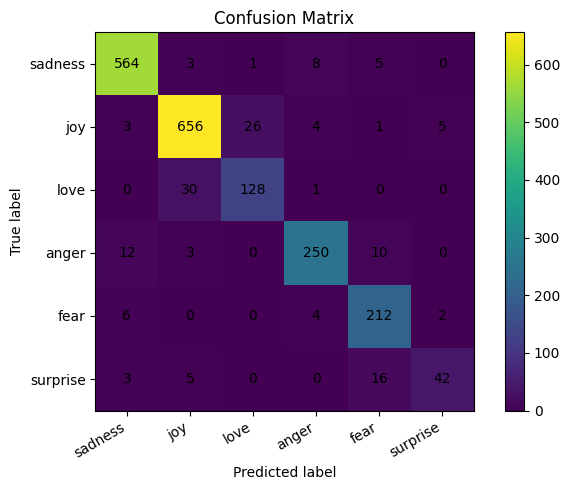

Saved: artifacts\confusion_matrix.png


In [41]:
cm = confusion_matrix(test_true, test_pred)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()

conf_matrix_path = ARTIFACTS_DIR / "confusion_matrix.png"
plt.savefig(conf_matrix_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", conf_matrix_path)

In [42]:
test_texts = [test_ds[i]["text"] for i in range(len(test_ds))]

predictions_df = pd.DataFrame({
    "text": test_texts,
    "true_label": [id2label[int(x)] for x in test_true],
    "pred_label": [id2label[int(x)] for x in test_pred],
    "confidence": test_conf,
})

display(predictions_df.head(10))

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.9989
1,im updating my blog because i feel shitty,sadness,sadness,0.9991
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.9991
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.9990
4,i was feeling a little vain when i did this one,sadness,sadness,0.9992
5,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,fear,0.9974
6,i felt anger when at the end of a telephone call,anger,anger,0.9970
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have been feeling for getti...,joy,joy,0.9891
8,i like to have the same breathless feeling as a reader eager to see what will happen next,joy,joy,0.9990
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on vacation for the summer,anger,anger,0.9980


In [43]:
sample_predictions_df = predictions_df.head(20).copy()

sample_predictions_path = ARTIFACTS_DIR / "sample_predictions.csv"
sample_predictions_df.to_csv(sample_predictions_path, index=False, encoding="utf-8")

print("Saved:", sample_predictions_path)
display(sample_predictions_df)

Saved: artifacts\sample_predictions.csv


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambitious right now,sadness,sadness,0.9989
1,im updating my blog because i feel shitty,sadness,sadness,0.9991
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,0.9991
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,joy,0.9990
4,i was feeling a little vain when i did this one,sadness,sadness,0.9992
5,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,fear,0.9974
6,i felt anger when at the end of a telephone call,anger,anger,0.9970
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have been feeling for getti...,joy,joy,0.9891
8,i like to have the same breathless feeling as a reader eager to see what will happen next,joy,joy,0.9990
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on vacation for the summer,anger,anger,0.9980


In [44]:
errors_df = predictions_df[predictions_df["true_label"] != predictions_df["pred_label"]].copy()
errors_df = errors_df.sort_values(by="confidence", ascending=False).reset_index(drop=True)

print("Number of errors on test:", len(errors_df))
display(errors_df.head(10))

Number of errors on test: 148


,text,true_label,pred_label,confidence
0,i actually was in a meeting last week where someone yelled at an older lady because her phone rang i felt terrible for her your boss treats you unfairly or ...,anger,sadness,0.9990
1,whenever i put myself in others shoes and try to make the person happy,anger,joy,0.9989
2,i feel very saddened that the king whom i once quite respected as far as monarchs go was ineffectual at best,joy,sadness,0.9989
3,i feel inside cause life is like a game sometimes but then you came around me the walls just disappeared nothing to surround me and keep me from my fears im...,fear,sadness,0.9983
4,i feel i can only hope im not alone in these thoughts and im sure to all you fellow exchange students you probably have the same thoughts in mind with at le...,sadness,joy,0.9979
5,i feel affirmed gracious sensuous and will have less self doubt when a href http generations,love,joy,0.9963
6,i just feel are ludicrous and wasting space or so trite they should have looked at the book first and come up with something a little more original,surprise,sadness,0.9962
7,i really dont like quinn because i feel like she will just end up hurting barney and i hated the lame ted robin storyline,anger,sadness,0.9953
8,i guess no matter how much i think im feeling ok im as nervous as hell on the inside about the scan revealing something i dont want to know again,joy,fear,0.9950
9,i felt confused me sometimes that makes me feel useless,sadness,fear,0.9938


## 8. Краткий анализ ошибок

Ниже нужно кратко прокомментировать несколько ошибок модели:
- какие классы путаются чаще всего;
- какие короткие или неоднозначные тексты вызывают проблемы;
- где в одном тексте смешаны несколько эмоций;
- в каких случаях модель ошибается уверенно.

## 9. Итоговый вывод

В этой работе был пройден полный базовый pipeline для текстовой классификации в HuggingFace:
от токенизации и анализа входов модели до fine-tuning и оценки на test-выборке.
Готовая pretrained-модель уже умела распознавать эмоции на разумном уровне,
а fine-tuning модели `distilbert-base-uncased` позволил адаптировать модель под выбранный датасет
и получить итоговые метрики `accuracy` и `f1_macro`.